# 复现当前 picture2 的绘图 notebook

这个 notebook 用于复现你当前 `results/picture2.svg` 的整体结构: 主曲线 + inset + 红色连接箭头。

使用说明:
1) 建议在 VSCode 中依次运行全部单元(或先 Run All)。
2) 若路径或环境不同, 只需修改配置单元中的变量。


In [1]:
from pathlib import Path
import json
import re
import sys
import importlib.util
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator, MultipleLocator
def find_project_root(explicit_project_root: str = '') -> Path:
    """
    用途: 定位项目根目录(需同时包含 plot 和 results 子目录)。
    参数:
    - explicit_project_root: str, 用户手动指定路径, 为空时走自动探测。
    返回:
    - Path, 项目根目录绝对路径。
    """
    if explicit_project_root.strip() != '':
        root = Path(explicit_project_root).expanduser().resolve()
        if (root / 'plot').is_dir() and (root / 'results').is_dir():
            return root
        raise FileNotFoundError(f'手动指定路径不是项目根目录: {root}')
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.extend(cwd.parents)
    candidates.append(Path(r'D:/study/研究生/科研/VMC/HKJ_s/mfVMC'))
    for root in candidates:
        if (root / 'plot').is_dir() and (root / 'results').is_dir():
            return root
    raise FileNotFoundError('无法自动定位项目根目录, 请在配置单元设置 explicit_project_root。')
def build_k_grid_2d(lattice_x: int, lattice_y: int, center: bool = False) -> tuple[np.ndarray, np.ndarray]:
    """
    用途: 构造二维动量点网格 KX, KY。
    参数:
    - lattice_x: int, x方向线性尺寸Lx。
    - lattice_y: int, y方向线性尺寸Ly。
    - center: bool, 是否将动量平移到[-pi, pi)区间。
    返回:
    - tuple[np.ndarray, np.ndarray], 网格化后的 KX 与 KY, shape均为 (Lx, Ly)。
    公式:
    - kx(i) = 2*pi*i/Lx, ky(j) = 2*pi*j/Ly
    """
    kx_values = 2.0 * np.pi / lattice_x * np.arange(lattice_x, dtype=float)
    ky_values = 2.0 * np.pi / lattice_y * np.arange(lattice_y, dtype=float)
    if center:
        kx_values = (kx_values + np.pi) % (2.0 * np.pi) - np.pi
        ky_values = (ky_values + np.pi) % (2.0 * np.pi) - np.pi
    grid_kx, grid_ky = np.meshgrid(kx_values, ky_values, indexing='ij')
    return grid_kx, grid_ky
def parse_ss_key(raw_key: str) -> tuple[int, int, int, int] | None:
    """
    用途: 解析 SS_all.json 中的键名。
    参数:
    - raw_key: str, 形如 'SS_x0_y0_x1_y1' 的键名。
    返回:
    - tuple[int, int, int, int] | None, 解析成功返回坐标元组, 失败返回None。
    """
    match_obj = re.fullmatch(r'SS_(\d+)_(\d+)_(\d+)_(\d+)', raw_key)
    if match_obj is None:
        return None
    return tuple(int(match_obj.group(index)) for index in range(1, 5))
def load_ss_terms(ss_all_json_path: Path, lattice_x: int, lattice_y: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    """
    用途: 从 SS_all.json 读取(位移, 权重)项, 并统计参与格点数Nsite。
    参数:
    - ss_all_json_path: Path, SS_all.json 文件路径。
    - lattice_x: int, Lx。
    - lattice_y: int, Ly。
    返回:
    - tuple[np.ndarray, np.ndarray, np.ndarray, int]
      - delta_x_array: 每项的 (x0-x1)
      - delta_y_array: 每项的 (y0-y1)
      - ss_value_array: 每项对应的SS权重
      - n_site: 在键集合中出现过的格点总数
    """
    if not ss_all_json_path.is_file():
        raise FileNotFoundError(f'SS_all.json 不存在: {ss_all_json_path}')
    raw_dict = json.loads(ss_all_json_path.read_text(encoding='utf-8'))
    if not isinstance(raw_dict, dict):
        raise ValueError(f'SS_all.json 不是字典结构: {ss_all_json_path}')
    delta_x_list: list[float] = []
    delta_y_list: list[float] = []
    ss_value_list: list[float] = []
    site_flag = np.zeros((lattice_x, lattice_y), dtype=bool)
    for raw_key, raw_value in raw_dict.items():
        parsed = parse_ss_key(str(raw_key))
        if parsed is None:
            continue
        x0, y0, x1, y1 = parsed
        if not (0 <= x0 < lattice_x and 0 <= x1 < lattice_x and 0 <= y0 < lattice_y and 0 <= y1 < lattice_y):
            continue
        try:
            ss_value = float(raw_value)
        except (TypeError, ValueError):
            continue
        delta_x_list.append(float(x0 - x1))
        delta_y_list.append(float(y0 - y1))
        ss_value_list.append(ss_value)
        site_flag[x0, y0] = True
        site_flag[x1, y1] = True
    if len(ss_value_list) == 0:
        raise ValueError(f'SS_all.json 无可用SS项: {ss_all_json_path}')
    delta_x_array = np.asarray(delta_x_list, dtype=float)
    delta_y_array = np.asarray(delta_y_list, dtype=float)
    ss_value_array = np.asarray(ss_value_list, dtype=float)
    n_site = int(np.count_nonzero(site_flag))
    return delta_x_array, delta_y_array, ss_value_array, n_site
def compute_structure_factor_map(
    ss_all_json_path: Path,
    lattice_x: int,
    lattice_y: int,
    chunk_size: int = 32,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    用途: 由 SS_all.json 计算 S(q) 二维矩阵。
    参数:
    - ss_all_json_path: Path, SS_all.json 文件路径。
    - lattice_x: int, Lx。
    - lattice_y: int, Ly。
    - chunk_size: int, 分块计算q点数量, 降低峰值内存。
    返回:
    - tuple[np.ndarray, np.ndarray, np.ndarray]
      - grid_kx: np.ndarray, KX网格
      - grid_ky: np.ndarray, KY网格
      - sq_map: np.ndarray, S(q)矩阵
    公式:
    - S(q) = [2 * sum_{(r0,r1)} cos(q·(r0-r1)) * SS(r0,r1) + Nsite*0.75] / (Lx*Ly)^2
    """
    grid_kx, grid_ky = build_k_grid_2d(lattice_x=lattice_x, lattice_y=lattice_y, center=False)
    delta_x_array, delta_y_array, ss_value_array, n_site = load_ss_terms(
        ss_all_json_path=ss_all_json_path,
        lattice_x=lattice_x,
        lattice_y=lattice_y,
    )
    flat_kx = grid_kx.ravel()
    flat_ky = grid_ky.ravel()
    flat_sq = np.zeros_like(flat_kx, dtype=float)
    term_count = delta_x_array.shape[0]
    start_index = 0
    while start_index < flat_kx.shape[0]:
        end_index = min(start_index + int(chunk_size), flat_kx.shape[0])
        chunk_kx = flat_kx[start_index:end_index][:, None]
        chunk_ky = flat_ky[start_index:end_index][:, None]
        phase_matrix = chunk_kx * delta_x_array[None, :] + chunk_ky * delta_y_array[None, :]
        chunk_sum = (2.0 * np.cos(phase_matrix) * ss_value_array[None, :]).sum(axis=1)
        flat_sq[start_index:end_index] = chunk_sum
        start_index = end_index
    normalization = float((lattice_x * lattice_y) ** 2)
    flat_sq = (flat_sq + float(n_site) * 0.75) / normalization
    sq_map = flat_sq.reshape((lattice_x, lattice_y))
    print(f'[INFO] SS项数量 = {term_count}, Nsite = {n_site}, file = {ss_all_json_path.name}')
    return grid_kx, grid_ky, sq_map
def format_pi_label(value: float, max_denominator: int = 24) -> str:
    """
    用途: 将实数k值格式化为pi单位标签。
    参数:
    - value: float, k值。
    - max_denominator: int, 分母上限, 用于有理近似。
    返回:
    - str, LaTeX风格的pi标签字符串。
    """
    if np.isclose(value, 0.0):
        return '0'
    ratio = float(value / np.pi)
    fraction_value = Fraction(ratio).limit_denominator(max_denominator)
    numerator = fraction_value.numerator
    denominator = fraction_value.denominator
    if denominator == 1:
        if numerator == 1:
            return r'$\pi$'
        return rf'${numerator}\pi$'
    if numerator == 1:
        return rf'$\pi/{denominator}$'
    return rf'${numerator}\pi/{denominator}$'
def build_pi_ticks(max_k: float) -> tuple[list[float], list[str]]:
    """
    用途: 生成不超过max_k的pi单位坐标轴tick, 并补充末端离散k点刻度。
    参数:
    - max_k: float, 坐标轴上限。
    返回:
    - tuple[list[float], list[str]], tick位置和对应标签。
    """
    base_positions = [0.0, np.pi, 2.0 * np.pi]
    base_labels = ['0', r'$\pi$', r'$2\pi$']
    tick_positions: list[float] = []
    tick_labels: list[str] = []
    for one_pos, one_label in zip(base_positions, base_labels):
        if one_pos <= max_k + 1e-10:
            tick_positions.append(float(one_pos))
            tick_labels.append(one_label)
    if len(tick_positions) == 0:
        tick_positions = [0.0]
        tick_labels = ['0']
    if abs(max_k - tick_positions[-1]) > 1e-6:
        tick_positions.append(float(max_k))
        tick_labels.append(format_pi_label(float(max_k)))
    return tick_positions, tick_labels
def apply_pi_ticks(axis_obj, max_k: float, show_y_ticklabels: bool) -> None:
    """
    用途: 将坐标轴tick设置为pi单位, 上限由max_k控制。
    参数:
    - axis_obj: matplotlib坐标轴对象。
    - max_k: float, 坐标轴上限。
    - show_y_ticklabels: bool, 是否显示y轴tick标签。
    返回:
    - None。
    """
    tick_positions, tick_labels = build_pi_ticks(max_k=max_k)
    axis_obj.set_xticks(tick_positions)
    axis_obj.set_xticklabels(tick_labels)
    axis_obj.set_yticks(tick_positions)
    if show_y_ticklabels:
        axis_obj.set_yticklabels(tick_labels)
print(f'python = {sys.executable}')
print(f'cwd    = {Path.cwd().resolve()}')


python = d:\software\anaconda3\envs\quspin\python.exe
cwd    = D:\study\研究生\科研\VMC\HKJ_s\mfVMC\plot


In [2]:
# =========================
# 配置区: 只改这里即可
# =========================
# 如果自动定位失败, 在这里填项目根目录绝对路径; 自动定位正常时保持空字符串
explicit_project_root = ''
project_root = find_project_root(explicit_project_root=explicit_project_root)
print(f'project_root = {project_root}')
# 主曲线数据源
l16_path = (project_root / 'results/L_16/J2_0.5_J3_1.25').resolve()
l18_path = (project_root / 'results/L_18/J2_0.5_J3_1.25').resolve()
l20_defect_average_combined_csv_path = (project_root / 'results/L_20/defect_average/picture2_defect_average_scalar_average_summary_combined.csv').resolve()
l12_path = (project_root / 'results/L_12/J2_0_J3_0').resolve()
benchmark_vmc_12_obc_csv_path = (project_root / 'results/benchmark_domain/auto_submit/best_sector_observables_vs_doping.csv').resolve()
benchmark_dmrg_12_obc_path = (project_root / 'results/benchmark_domain/DMRG.txt').resolve()
benchmark_dmrg_lattice_size = 12
benchmark_dmrg_mz_col = 'mz'
hole_series_inputs = []
electron_series_inputs = []
# 三张下排S(q)配置: 依次对应左/中/右子图
# panel_tag用于子图红色标注 (b)(c)(d)
# sq_tag用于主图虚线标注 S1/S2/S3, 并与下方S(q)对应
# doping_range表示该S(q)对应的doping位置区间 [xmin, xmax]
sq_panel_configs = [
    {
        'panel_tag': '(b)',
        'sq_tag': 'S1',
        'panel_label': 'S(q)',
        'sq_npz_path': project_root / 'results/L_20/defect_average/electron/Ndefect24/logs/average_picture2/sq_map_average.npz',
        'doping_range': (-0.075, -0.049),
    },
    {
        'panel_tag': '(c)',
        'sq_tag': 'S2',
        'panel_label': 'S(q)',
        'sq_npz_path': project_root / 'results/L_20/defect_average/hole/Ndefect18/logs/average_picture2/sq_map_average.npz',
        'doping_range': (0.035, 0.055),
    },
    {
        'panel_tag': '(d)',
        'sq_tag': 'S3',
        'panel_label': 'S(q)',
        'sq_npz_path': project_root / 'results/L_20/defect_average/hole/Ndefect42/logs/average_picture2/sq_map_average.npz',
        'doping_range': (0.095, 0.115),
    },
]
# 主图phase半透明区域配置(与S1/S2/S3虚线解耦, 你可手动调区间)
phase_region_configs = [
    {
        'phase_name': 'Phase-I',
        'doping_range': (-0.14, 0.07),
        'phase_color': '#9ECAE1',
    },
    {
        'phase_name': 'Phase-II',
        'doping_range': (0.07, 0.10),
        'phase_color': '#A1D99B',
    },
    {
        'phase_name': 'Phase-III',
        'doping_range': (0.10, 0.14),
        'phase_color': '#FDD0A2',
    },
]
# 输出文件
output_svg = project_root / 'results/picture2_from_notebook.svg'
output_pdf = project_root / 'results/picture2_from_notebook.pdf'
# 数据列配置
doping_col = 'doping'
ndefect_col = 'Ndefect'
mz_col = 'staggered_mz'
summary_name = 'summary_min_sector_staggered_mz_S_pi_pi.csv'
# S(q)计算参数
sq_chunk_size = 32
sq_level_count = 48
# =========================
# 科研绘图风格参数
# =========================
# 主图曲线: 使用色盲友好配色(Okabe-Ito家族)
curve_style_map = {
    'L=12': {'color': '#D55E00', 'marker': 'D'},
    'L=16': {'color': '#0072B2', 'marker': 'o'},
    'L=18': {'color': '#009E73', 'marker': 's'},
    'L=20': {'color': '#CC79A7', 'marker': '^'},
    'L=20 defect avg': {'color': '#CC79A7', 'marker': '^', 'linestyle': '-'},
    'VMC 12 OBC': {'color': '#4C78A8', 'marker': 'P'},
    'DMRG 12 OBC': {'color': '#222222', 'marker': 'X', 'linestyle': (0, (3.0, 1.8))},
}
# 线型: hole 实线, electron 虚线
hole_linestyle = '-'
electron_linestyle = (0, (5, 2.2))
main_linewidth = 2.0
main_markersize = 5.8
main_marker_edgewidth = 0.9
main_marker_edgecolor = '#FFFFFF'
main_grid_color = '#B8B8B8'
main_grid_alpha = 0.16
main_grid_linewidth = 0.7
main_show_grid = False
main_spine_linewidth = 0.9
main_tick_width = 0.9
main_tick_length = 4.2
main_tick_labelsize = 10.5
main_label_fontsize = 10
main_legend_fontsize = 8.8
main_legend_loc = 'lower left'
main_legend_bbox = (0.015, 0.03)
main_vline_color = '#666666'
main_vline_linestyle = '-'
main_vline_linewidth = 1.0
main_vline_alpha = 0.9
# 主图左右双面板配置: 缩小electron半区, 强调hole半区
main_split_width_ratios = (1.0, 2.2)
main_split_wspace = 0.0
main_electron_xlim = (-0.14, 0.0)
main_hole_xlim = (0.0, 0.14)
main_x_tick_step = 0.04
# S(q) 子图风格
sq_cmap = 'cividis'
sq_title_fontsize = 9
sq_tick_labelsize = 9.5
sq_tick_width = 0.8
sq_tick_length = 3.4
sq_spine_linewidth = 0.8
sq_peak_marker_color = '#00E5FF'
sq_peak_marker_size = 58
sq_peak_marker_linewidth = 1.1
# 布局与文字间距
layout_hspace = 0.28
layout_wspace = 0.02
figure_width = 8.6
figure_height = 7.4
main_row_ratio = 2.0
sq_row_ratio = 1.45
main_xlabel_pad = 8.0
sq_title_pad = 1.5
# colorbar 美化
colorbar_tick_count = 5
colorbar_tick_format = '%.2f'
colorbar_label = r'relative $S(\mathbf{q})$'
colorbar_label_fontsize = 9
colorbar_label_pad = 5.0
colorbar_outline_linewidth = 0.6
colorbar_relative_pad = 0.006
colorbar_relative_width = 0.012
# 主图doping区间阴影样式(用于映射到下方S(q))
zone_fill_color = '#8F8F8F'
zone_fill_alpha = 0.4
zone_label_fontsize = 8.8
zone_label_color = '#2F2F2F'
zone_label_offset_ratio = 0.05
zone_line_style = (0, (4.0, 2.5))
zone_line_width = 1.15
zone_line_alpha = 0.95
sq_marker_line_color = '#4F4F4F'
sq_marker_label_fontsize = 9.0
sq_marker_label_color = '#2F2F2F'
sq_marker_label_offset_ratio = 0.05
sq_marker_label_dx = 0.0025
# 子图标签(a)(b)(c)(d)样式
main_panel_tag = '(a)'
subfigure_label_color = '#C62828'
subfigure_label_fontsize = 12.2
subfigure_label_fontweight = 'bold'
# 主图左下electron区域S(q) inset配置
electron_inset_enabled = False
electron_inset_panel_index = 0
electron_inset_rect = [0.05, 0.06, 0.35, 0.35]  # [left, bottom, width, height] in axis_main coordinates
electron_inset_title = r'electron $S(\mathbf{q})$'
electron_inset_title_fontsize = 7.8
electron_inset_show_ticks = False
electron_inset_spine_linewidth = 0.8
# 主图phase标注配置(坐标为主图数据坐标)
phase_label_fontsize = 11.6
phase_label_color = '#1F1F1F'
phase_label_fontweight = 'bold'
phase_annotations = [
    (-0.05, 0.2, 'AFM'),
    (0.02, 0.1, 'AFM'),
    (0.1, 0.2, 'Weak AFM / Spin Glass'),
]


project_root = D:\study\研究生\科研\VMC\HKJ_s\mfVMC


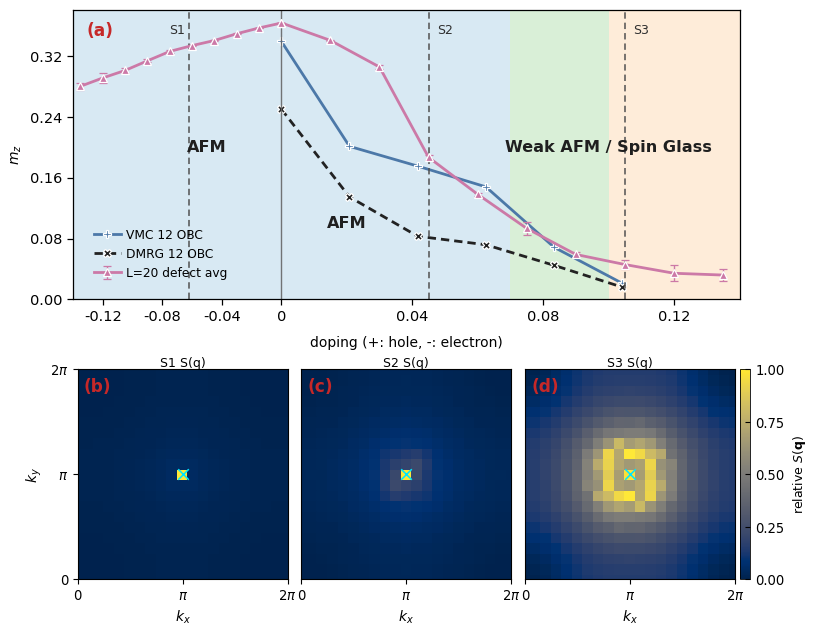

[OK] 输出 SVG: D:\study\研究生\科研\VMC\HKJ_s\mfVMC\results\picture2_from_notebook.svg
[OK] 输出 PDF: D:\study\研究生\科研\VMC\HKJ_s\mfVMC\results\picture2_from_notebook.pdf


In [3]:
module_path = project_root / 'plot/plot_abs_staggered_mz_bipolar_simple.py'
if not module_path.is_file():
    raise FileNotFoundError(f'找不到脚本文件: {module_path}')
spec = importlib.util.spec_from_file_location('plot_abs_staggered_mz_bipolar_simple', module_path)
if spec is None or spec.loader is None:
    raise ImportError(f'无法创建模块加载器: {module_path}')
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
collect_series_data = module.collect_series_data
load_one_series = module.load_one_series
if len(hole_series_inputs) + len(electron_series_inputs) > 0:
    all_series = collect_series_data(
        hole_series_inputs=hole_series_inputs,
        electron_series_inputs=electron_series_inputs,
        doping_col=doping_col,
        ndefect_col=ndefect_col,
        staggered_mz_col=mz_col,
        summary_name=summary_name,
    )
else:
    all_series = []
# 接入 L=20 defect_average 数据(替换原 auto_submit), 并在主图中绘制 error bar
if not l20_defect_average_combined_csv_path.is_file():
    raise FileNotFoundError(f'L20 defect_average 汇总文件不存在: {l20_defect_average_combined_csv_path}')
l20_defect_average_array = np.genfromtxt(
    l20_defect_average_combined_csv_path,
    names=True,
    delimiter=',',
    dtype=None,
    encoding='utf-8-sig',
)
l20_defect_average_array = np.atleast_1d(l20_defect_average_array)
l20_defect_average_phase = np.asarray(l20_defect_average_array['phase']).astype(str)
l20_defect_average_doping = np.asarray(l20_defect_average_array['signed_doping'], dtype=float)
l20_defect_average_mz = np.asarray(l20_defect_average_array['abs_staggered_mz_mean'], dtype=float)
l20_defect_average_mz_se = np.asarray(l20_defect_average_array['abs_staggered_mz_se'], dtype=float)
def build_l20_defect_average_series(phase_name):
    phase_mask = l20_defect_average_phase == phase_name
    phase_x = l20_defect_average_doping[phase_mask]
    phase_y = l20_defect_average_mz[phase_mask]
    phase_yerr = l20_defect_average_mz_se[phase_mask]
    valid_mask = np.isfinite(phase_x) & np.isfinite(phase_y)
    phase_x = phase_x[valid_mask]
    phase_y = phase_y[valid_mask]
    phase_yerr = phase_yerr[valid_mask]
    phase_yerr = np.where(np.isfinite(phase_yerr), phase_yerr, 0.0)
    if phase_x.size == 0:
        raise ValueError(f'L20 defect_average 缺少 phase={phase_name} 的有效数据')
    sort_index = np.argsort(phase_x)
    return phase_x[sort_index], phase_y[sort_index], phase_yerr[sort_index]
l20_defect_average_hole_x, l20_defect_average_hole_y, l20_defect_average_hole_yerr = build_l20_defect_average_series('hole')
l20_defect_average_electron_x, l20_defect_average_electron_y, l20_defect_average_electron_yerr = build_l20_defect_average_series('electron')
l20_defect_average_series = [
    ('L=20 defect avg', 'hole', l20_defect_average_hole_x, l20_defect_average_hole_y, l20_defect_average_hole_yerr),
    ('L=20 defect avg', 'electron', l20_defect_average_electron_x, l20_defect_average_electron_y, l20_defect_average_electron_yerr),
]
# 追加hole半区benchmark曲线: VMC 12 OBC 与 DMRG 12 OBC
benchmark_vmc_12_obc_x, benchmark_vmc_12_obc_y = load_one_series(
    series_label='VMC 12 OBC',
    raw_path=Path(benchmark_vmc_12_obc_csv_path).resolve(),
    lattice_size=None,
    doping_col=doping_col,
    ndefect_col=ndefect_col,
    staggered_mz_col=mz_col,
    doping_type='hole',
    summary_name=summary_name,
)
all_series.append(('VMC 12 OBC', 'hole', benchmark_vmc_12_obc_x, benchmark_vmc_12_obc_y))
# DMRG.txt为tab分隔文本, 这里单独解析并转换到hole半区doping
benchmark_dmrg_array = np.genfromtxt(
    Path(benchmark_dmrg_12_obc_path).resolve(),
    names=True,
    delimiter='	',
    dtype=float,
    encoding='utf-8-sig',
)
benchmark_dmrg_ndefect = np.atleast_1d(benchmark_dmrg_array[ndefect_col])
benchmark_dmrg_mz = np.atleast_1d(benchmark_dmrg_array[benchmark_dmrg_mz_col])
benchmark_dmrg_12_obc_x = np.abs(benchmark_dmrg_ndefect) / float(int(benchmark_dmrg_lattice_size) ** 2)
benchmark_dmrg_12_obc_y = np.abs(benchmark_dmrg_mz)
benchmark_dmrg_sort_index = np.argsort(benchmark_dmrg_12_obc_x)
benchmark_dmrg_12_obc_x = benchmark_dmrg_12_obc_x[benchmark_dmrg_sort_index]
benchmark_dmrg_12_obc_y = benchmark_dmrg_12_obc_y[benchmark_dmrg_sort_index]
all_series.append(('DMRG 12 OBC', 'hole', benchmark_dmrg_12_obc_x, benchmark_dmrg_12_obc_y))
sq_maps = []
for panel_config in sq_panel_configs:
    sq_npz_path = Path(panel_config['sq_npz_path']).resolve()
    if not sq_npz_path.is_file():
        raise FileNotFoundError(f'S(q)平均图文件不存在: {sq_npz_path}')
    with np.load(sq_npz_path, allow_pickle=True) as sq_npz_data:
        sq_map = np.asarray(sq_npz_data['sq_mean'], dtype=float)
        grid_kx = np.asarray(sq_npz_data['kx_grid'], dtype=float)
        grid_ky = np.asarray(sq_npz_data['ky_grid'], dtype=float)
    sq_min = float(np.min(sq_map))
    sq_max = float(np.max(sq_map))
    sq_span = sq_max - sq_min
    if np.isclose(sq_span, 0.0):
        sq_map_relative = np.zeros_like(sq_map)
    else:
        sq_map_relative = (sq_map - sq_min) / sq_span
    sq_maps.append((grid_kx, grid_ky, sq_map_relative))
figure = plt.figure(figsize=(figure_width, figure_height), constrained_layout=False)
grid_spec = figure.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[main_row_ratio, sq_row_ratio],
    hspace=layout_hspace,
    wspace=layout_wspace,
)
# 主图使用单一坐标轴, 通过分段线性映射实现正负doping不同视觉比例
axis_main = figure.add_subplot(grid_spec[0, :])
left_visual_width = float(main_split_width_ratios[0])
right_visual_width = float(main_split_width_ratios[1])
left_denom = max(1e-12, 0.0 - float(main_electron_xlim[0]))
right_denom = max(1e-12, float(main_hole_xlim[1]) - 0.0)
def transform_doping_for_main_axis(doping_values):
    doping_array = np.asarray(doping_values, dtype=float)
    mapped_array = np.empty_like(doping_array, dtype=float)
    negative_mask = doping_array <= 0.0
    mapped_array[negative_mask] = left_visual_width * doping_array[negative_mask] / left_denom
    mapped_array[~negative_mask] = right_visual_width * doping_array[~negative_mask] / right_denom
    return mapped_array
def format_doping_tick_label(doping_value):
    if np.isclose(doping_value, 0.0):
        return '0'
    return f'{doping_value:.2f}'.rstrip('0').rstrip('.')
# 主曲线
for series_label, doping_type, x_values, y_values in all_series:
    default_style = {'color': '#444444', 'marker': 'o'}
    curve_style = curve_style_map.get(series_label, default_style)
    line_style = curve_style.get(
        'linestyle',
        hole_linestyle if doping_type == 'hole' else electron_linestyle,
    )
    mapped_x_values = transform_doping_for_main_axis(x_values)
    axis_main.plot(
        mapped_x_values,
        y_values,
        marker=curve_style['marker'],
        linestyle=line_style,
        linewidth=main_linewidth,
        markersize=main_markersize,
        color=curve_style['color'],
        markerfacecolor=curve_style['color'],
        markeredgecolor=main_marker_edgecolor,
        markeredgewidth=main_marker_edgewidth,
        label=series_label,
    )
# L=20 defect_average 曲线使用 error bar, 其余曲线保持原样
for series_index, (series_label, doping_type, x_values, y_values, y_errors) in enumerate(l20_defect_average_series):
    default_style = {'color': '#444444', 'marker': 'o'}
    curve_style = curve_style_map.get(series_label, default_style)
    line_style = curve_style.get(
        'linestyle',
        hole_linestyle if doping_type == 'hole' else electron_linestyle,
    )
    mapped_x_values = transform_doping_for_main_axis(x_values)
    legend_label = series_label if series_index == 0 else '_nolegend_'
    axis_main.errorbar(
        mapped_x_values,
        y_values,
        yerr=y_errors,
        marker=curve_style['marker'],
        linestyle=line_style,
        linewidth=main_linewidth,
        markersize=main_markersize,
        color=curve_style['color'],
        markerfacecolor=curve_style['color'],
        markeredgecolor=main_marker_edgecolor,
        markeredgewidth=main_marker_edgewidth,
        elinewidth=1.0,
        capsize=2.8,
        capthick=1.0,
        label=legend_label,
    )
# doping=0参考线
axis_main.axvline(
    0.0,
    color=main_vline_color,
    linestyle=main_vline_linestyle,
    linewidth=main_vline_linewidth,
    alpha=main_vline_alpha,
)
axis_main.set_xlim(-left_visual_width, right_visual_width)
axis_main.set_ylim(bottom=0.0)
if main_show_grid:
    axis_main.grid(color=main_grid_color, alpha=main_grid_alpha, linewidth=main_grid_linewidth)
axis_main.tick_params(
    axis='both',
    width=main_tick_width,
    length=main_tick_length,
    labelsize=main_tick_labelsize,
)
for one_spine in axis_main.spines.values():
    one_spine.set_linewidth(main_spine_linewidth)
axis_main.set_ylabel(r'$m_z$', fontsize=main_label_fontsize)
axis_main.set_xlabel('doping (+: hole, -: electron)', fontsize=main_label_fontsize, labelpad=main_xlabel_pad)
axis_main.yaxis.set_major_locator(MaxNLocator(nbins=5))
# x轴tick: 仍以真实doping值定义, 仅显示坐标使用分段映射
right_ticks_doping = np.arange(0.0, float(main_hole_xlim[1]) + 0.5 * float(main_x_tick_step), float(main_x_tick_step))
left_tick_count = int(np.floor((0.0 - float(main_electron_xlim[0])) / float(main_x_tick_step)))
left_ticks_doping = -float(main_x_tick_step) * np.arange(left_tick_count, 0, -1, dtype=float)
left_ticks_doping = left_ticks_doping[left_ticks_doping >= float(main_electron_xlim[0]) - 1e-12]
all_ticks_doping = np.concatenate([left_ticks_doping, right_ticks_doping])
all_ticks_display = transform_doping_for_main_axis(all_ticks_doping)
axis_main.set_xticks(np.round(all_ticks_display, 10))
axis_main.set_xticklabels([format_doping_tick_label(one_tick) for one_tick in all_ticks_doping])
# 主图phase背景区域(独立配置)
for phase_region in phase_region_configs:
    x_start, x_end = phase_region['doping_range']
    x_start = float(x_start)
    x_end = float(x_end)
    if x_start > x_end:
        x_start, x_end = x_end, x_start
    mapped_start = float(transform_doping_for_main_axis([x_start])[0])
    mapped_end = float(transform_doping_for_main_axis([x_end])[0])
    axis_main.axvspan(
        min(mapped_start, mapped_end),
        max(mapped_start, mapped_end),
        color=phase_region.get('phase_color', zone_fill_color),
        alpha=zone_fill_alpha,
        zorder=0,
        lw=0.0,
    )
# 用中性虚线标记S1/S2/S3对应doping位置, 与phase背景解耦
y_min, y_max = axis_main.get_ylim()
sq_marker_text_y = y_max - sq_marker_label_offset_ratio * (y_max - y_min)
for panel_config in sq_panel_configs:
    x_start, x_end = panel_config['doping_range']
    x_center = 0.5 * (float(x_start) + float(x_end))
    x_center_display = float(transform_doping_for_main_axis([x_center])[0])
    axis_main.axvline(
        x_center_display,
        color=sq_marker_line_color,
        linestyle=zone_line_style,
        linewidth=zone_line_width,
        alpha=zone_line_alpha,
        zorder=2,
    )
    if x_center >= 0.0:
        marker_text_dx = right_visual_width * float(sq_marker_label_dx) / right_denom
        marker_text_x = x_center_display + marker_text_dx
        marker_text_ha = 'left'
    else:
        marker_text_dx = left_visual_width * float(sq_marker_label_dx) / left_denom
        marker_text_x = x_center_display - marker_text_dx
        marker_text_ha = 'right'
    axis_main.text(
        marker_text_x,
        sq_marker_text_y,
        panel_config['sq_tag'],
        ha=marker_text_ha,
        va='top',
        fontsize=sq_marker_label_fontsize,
        color=sq_marker_label_color,
    )
# 主图基态phase文本标注
for phase_x, phase_y, phase_text in phase_annotations:
    mapped_phase_x = float(transform_doping_for_main_axis([float(phase_x)])[0])
    axis_main.text(
        mapped_phase_x,
        float(phase_y),
        phase_text,
        fontsize=phase_label_fontsize,
        color=phase_label_color,
        fontweight=phase_label_fontweight,
        ha='center',
        va='center',
    )
axis_main.text(
    0.02,
    0.96,
    main_panel_tag,
    transform=axis_main.transAxes,
    ha='left',
    va='top',
    fontsize=subfigure_label_fontsize,
    color=subfigure_label_color,
    fontweight=subfigure_label_fontweight,
)
legend_handles, legend_labels = axis_main.get_legend_handles_labels()
if len(legend_handles) > 0:
    axis_main.legend(
        legend_handles,
        legend_labels,
        frameon=False,
        fontsize=main_legend_fontsize,
        loc=main_legend_loc,
        bbox_to_anchor=main_legend_bbox,
        handlelength=2.2,
        handletextpad=0.4,
    )
# 在主图左下空白区添加electron区域S(q) inset
if electron_inset_enabled:
    inset_panel_index = int(electron_inset_panel_index)
    if not (0 <= inset_panel_index < len(sq_maps)):
        raise ValueError(f'electron_inset_panel_index 超出范围: {inset_panel_index}')
    inset_axis = axis_main.inset_axes(electron_inset_rect)
    inset_grid_kx, inset_grid_ky, inset_sq_map_relative = sq_maps[inset_panel_index]
    inset_lattice_size = int(inset_sq_map_relative.shape[0])
    inset_delta_k = 2.0 * np.pi / float(inset_lattice_size)
    inset_sq_map_periodic = np.pad(inset_sq_map_relative, ((0, 1), (0, 1)), mode='wrap')
    inset_k_edges = np.linspace(-0.5 * inset_delta_k, 2.0 * np.pi + 0.5 * inset_delta_k, inset_lattice_size + 2)
    inset_edge_kx, inset_edge_ky = np.meshgrid(inset_k_edges, inset_k_edges, indexing='ij')
    inset_axis.pcolor(
        inset_edge_kx,
        inset_edge_ky,
        inset_sq_map_periodic,
        cmap=sq_cmap,
        vmin=0.0,
        vmax=1.0,
        edgecolors='none',
        antialiased=False,
    )
    inset_axis.scatter(
        np.pi,
        np.pi,
        c=sq_peak_marker_color,
        marker='x',
        s=sq_peak_marker_size * 0.55,
        linewidths=sq_peak_marker_linewidth,
        zorder=4,
    )
    inset_axis.set_xlim(0.0, 2.0 * np.pi)
    inset_axis.set_ylim(0.0, 2.0 * np.pi)
    inset_axis.set_aspect('equal', adjustable='box')
    inset_axis.set_title(electron_inset_title, fontsize=electron_inset_title_fontsize, pad=1.2)
    if electron_inset_show_ticks:
        apply_pi_ticks(inset_axis, max_k=2.0 * np.pi, show_y_ticklabels=True)
        inset_axis.tick_params(axis='both', width=sq_tick_width, length=sq_tick_length, labelsize=max(6.0, sq_tick_labelsize - 1.2))
    else:
        inset_axis.set_xticks([])
        inset_axis.set_yticks([])
    for one_spine in inset_axis.spines.values():
        one_spine.set_linewidth(electron_inset_spine_linewidth)
# 底部三张并排S(q), 共享ky轴
sq_axes = []
contour_artist = None
for panel_index, panel_config in enumerate(sq_panel_configs):
    axis_sq = figure.add_subplot(grid_spec[1, panel_index])
    sq_axes.append(axis_sq)
    grid_kx, grid_ky, sq_map_relative = sq_maps[panel_index]
    # 离散块绘制: 半格偏移边界 + 周期补一圈, 保证(pi,pi)落在色块中心
    lattice_size = int(sq_map_relative.shape[0])
    delta_k = 2.0 * np.pi / float(lattice_size)
    # 周期补一圈, 让0和2pi端点处色块连续
    sq_map_periodic = np.pad(sq_map_relative, ((0, 1), (0, 1)), mode='wrap')
    # 边界从 -dk/2 到 2pi+dk/2, 对应中心点 0, dk, ..., 2pi
    k_edges = np.linspace(-0.5 * delta_k, 2.0 * np.pi + 0.5 * delta_k, lattice_size + 2)
    edge_kx, edge_ky = np.meshgrid(k_edges, k_edges, indexing='ij')
    contour_artist = axis_sq.pcolor(
        edge_kx,
        edge_ky,
        sq_map_periodic,
        cmap=sq_cmap,
        vmin=0.0,
        vmax=1.0,
        edgecolors='none',
        antialiased=False,
    )
    axis_sq.scatter(
        np.pi,
        np.pi,
        c=sq_peak_marker_color,
        marker='x',
        s=sq_peak_marker_size,
        linewidths=sq_peak_marker_linewidth,
        zorder=4,
    )
    axis_sq.set_xlim(0.0, 2.0 * np.pi)
    axis_sq.set_ylim(0.0, 2.0 * np.pi)
    axis_sq.set_aspect('equal', adjustable='box')
    axis_sq.set_xlabel(r'$k_x$', fontsize=main_label_fontsize)
    axis_sq.set_title(f"{panel_config['sq_tag']} {panel_config['panel_label']}", fontsize=sq_title_fontsize, pad=sq_title_pad)
    axis_sq.text(
        0.03,
        0.96,
        panel_config['panel_tag'],
        transform=axis_sq.transAxes,
        ha='left',
        va='top',
        fontsize=subfigure_label_fontsize,
        color=subfigure_label_color,
        fontweight=subfigure_label_fontweight,
    )
    apply_pi_ticks(axis_sq, max_k=2.0 * np.pi, show_y_ticklabels=(panel_index == 0))
    axis_sq.tick_params(
        axis='x',
        width=sq_tick_width,
        length=sq_tick_length,
        labelsize=sq_tick_labelsize,
    )
    if panel_index == 0:
        axis_sq.set_ylabel(r'$k_y$', fontsize=main_label_fontsize)
        axis_sq.tick_params(
            axis='y',
            labelleft=True,
            left=True,
            width=sq_tick_width,
            length=sq_tick_length,
            labelsize=sq_tick_labelsize,
        )
    else:
        axis_sq.tick_params(axis='y', labelleft=False, left=False)
    for one_spine in axis_sq.spines.values():
        one_spine.set_linewidth(sq_spine_linewidth)
# colorbar贴在最右侧S(q)旁边, 去掉右侧大空白
if contour_artist is None:
    raise RuntimeError('S(q)绘制失败: contour对象为空')
last_sq_pos = sq_axes[-1].get_position()
axis_cbar = figure.add_axes([
    last_sq_pos.x1 + colorbar_relative_pad,
    last_sq_pos.y0,
    colorbar_relative_width,
    last_sq_pos.height,
])
colorbar = figure.colorbar(contour_artist, cax=axis_cbar)
colorbar_ticks = np.linspace(0.0, 1.0, int(colorbar_tick_count))
colorbar.set_ticks(colorbar_ticks)
colorbar.ax.yaxis.set_major_formatter(FormatStrFormatter(colorbar_tick_format))
colorbar.set_label(colorbar_label, fontsize=colorbar_label_fontsize, labelpad=colorbar_label_pad)
colorbar.ax.tick_params(
    labelsize=sq_tick_labelsize,
    width=sq_tick_width,
    length=sq_tick_length,
    direction='in',
)
colorbar.outline.set_linewidth(colorbar_outline_linewidth)
figure.savefig(output_svg, format='svg')
figure.savefig(output_pdf, format='pdf')
plt.show()
plt.close(figure)
print(f'[OK] 输出 SVG: {output_svg}')
print(f'[OK] 输出 PDF: {output_pdf}')
